# Clase Extensiva: REBOUND para Mecánica Celeste en Python

**Autor:** Clase de Mecánica Celeste  
**Fecha:** 2026  

---

## ¿Qué es REBOUND?

[REBOUND](https://rebound.readthedocs.io/) es una librería de N-cuerpos de código abierto, escrita principalmente en C con una interfaz completa en Python. Fue desarrollada por Hanno Rein y colaboradores, y es ampliamente utilizada en astrofísica y mecánica celeste para:

- Simular el movimiento de planetas, asteroides y satélites.
- Estudiar resonancias orbitales y estabilidad de sistemas planetarios.
- Modelar encuentros cercanos y colisiones.
- Integrar sistemas de N-cuerpos con alta precisión y velocidad.

## Estructura de este cuaderno

1. Instalación y configuración
2. Conceptos fundamentales: `Simulation`, `Particle`, `Integrators`
3. Problema de dos cuerpos — el problema de Kepler
4. Elementos orbitales en REBOUND
5. Uso de la base de datos NASA Horizons
6. Sistema Solar: simulación del sistema interior
7. Integradores numéricos disponibles
8. Conservación de energía y momento angular
9. Detección de encuentros cercanos y colisiones
10. Visualización 2-D y 3-D
11. Resonancias de movimiento medio
12. `SimulationArchive`: guardar y restaurar simulaciones
13. Funciones de latido (`heartbeat`) y monitoreo en tiempo real
14. Caso de aplicación: Apophis y su aproximación a la Tierra
15. Ejercicios propuestos

---

## 1. Instalación y configuración

REBOUND se instala fácilmente con `pip`. También necesitaremos `numpy`, `matplotlib` y opcionalmente `plotly` para visualizaciones.

In [1]:
# Instalar las dependencias (ejecutar solo si no están instaladas)
!pip install rebound numpy matplotlib plotly -Uq

In [2]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

print(f"Versión de REBOUND: {rebound.__version__}")

Matplotlib is building the font cache; this may take a moment.


Versión de REBOUND: 4.6.0


In [3]:
# Deshabilitar verificación SSL para consultas a NASA Horizons
# (necesario en algunos entornos sin certificados actualizados)
import rebound.horizons
rebound.horizons.SSL_CONTEXT = 'unverified'

---

## 2. Conceptos fundamentales

### 2.1 La clase `Simulation`

El objeto central en REBOUND es `rebound.Simulation()`. Representa un sistema de N-cuerpos completo y contiene:

| Atributo / método | Descripción |
|---|---|
| `sim.t` | Tiempo actual de la simulación |
| `sim.N` | Número de partículas |
| `sim.particles` | Lista de partículas (objetos `Particle`) |
| `sim.add(...)` | Agregar una partícula |
| `sim.integrate(t)` | Avanzar la simulación hasta el tiempo `t` |
| `sim.move_to_com()` | Mover el sistema al centro de masa |
| `sim.status()` | Imprimir el estado actual |
| `sim.G` | Constante gravitacional (por defecto 1 en unidades de N-cuerpos) |

### 2.2 La clase `Particle`

Cada partícula (`rebound.Particle`) tiene los siguientes atributos:

| Atributo | Descripción |
|---|---|
| `p.m` | Masa |
| `p.x, p.y, p.z` | Posición |
| `p.vx, p.vy, p.vz` | Velocidad |
| `p.ax, p.ay, p.az` | Aceleración |
| `p.r` | Radio (para detección de colisiones) |
| `p.hash` | Identificador único (entero o string) |
| `p.a, p.e, p.inc` | Elementos orbitales (semieje mayor, excentricidad, inclinación) |

In [4]:
# === Ejemplo mínimo ===
sim = rebound.Simulation()

# Agregar el Sol (masa en unidades solares, posición y velocidad en el origen)
sim.add(m=1.0)  # El Sol

# Agregar la Tierra a 1 UA con la velocidad orbital circular
# En unidades de N-cuerpos: G=1, M_sol=1 → v_circular = sqrt(G*M/r) = 1 para r=1
sim.add(m=3e-6, x=1.0, vy=1.0)  # Tierra (masa en unidades solares ≈ 3e-6)

# Mover al centro de masa
sim.move_to_com()

print(f"Número de partículas: {sim.N}")
print(f"Tiempo inicial: {sim.t}")

# Acceder a partículas por índice
sol = sim.particles[0]
tierra = sim.particles[1]

print(f"\nSol — masa: {sol.m:.3e}, posición: ({sol.x:.4f}, {sol.y:.4f}, {sol.z:.4f})")
print(f"Tierra — masa: {tierra.m:.3e}, posición: ({tierra.x:.4f}, {tierra.y:.4f}, {tierra.z:.4f})")

Número de partículas: 2
Tiempo inicial: 0.0

Sol — masa: 1.000e+00, posición: (-0.0000, 0.0000, 0.0000)
Tierra — masa: 3.000e-06, posición: (1.0000, 0.0000, 0.0000)


---

## 3. Problema de dos cuerpos — El problema de Kepler

El problema de Kepler es el caso más simple de N-cuerpos: una partícula de prueba orbitando un cuerpo masivo. La solución analítica da órbitas elípticas, parabólicas o hiperbólicas según la energía total del sistema.

**Energía total:**
$$E = \frac{1}{2}\mu v^2 - \frac{G M m}{r}$$

- $E < 0$: órbita elíptica (ligada)
- $E = 0$: trayectoria parabólica
- $E > 0$: trayectoria hiperbólica

**Período orbital** (3ª Ley de Kepler):
$$T = 2\pi \sqrt{\frac{a^3}{G M}}$$

En unidades de N-cuerpos con $G=1$, $M_{\odot}=1$, 1 UA, el período de la Tierra es $T = 2\pi$ años.

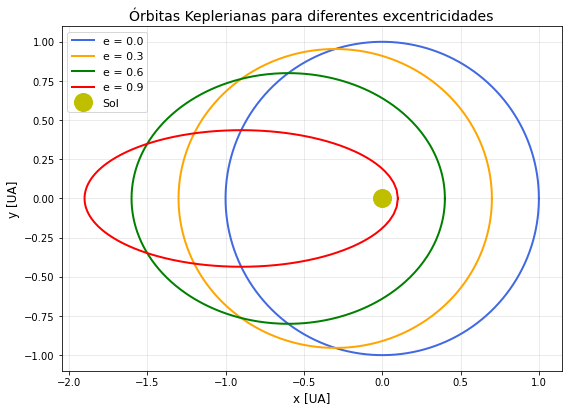

Período para a=1 UA: T = 6.2832 unidades de tiempo
  (equivalente a 1 año para la Tierra, dado G=1, M_sol=1, 1 UA)


In [5]:
# === Simulación del problema de Kepler ===

def simular_orbita_kepler(a=1.0, e=0.0, n_orbitas=3, n_puntos=500):
    """
    Simula una partícula en órbita kepleriana alrededor del Sol.
    
    Parámetros
    ----------
    a : float
        Semieje mayor en UA
    e : float
        Excentricidad orbital (0 = circular, 0 < e < 1 = elíptica)
    n_orbitas : int
        Número de órbitas completas a simular
    n_puntos : int
        Número de puntos de muestreo
    """
    sim = rebound.Simulation()
    sim.add(m=1.0)  # Sol
    # Agregar partícula con elementos orbitales
    sim.add(m=0, a=a, e=e)  # m=0: partícula de prueba
    sim.move_to_com()

    # Período orbital según la 3ª ley de Kepler
    T = 2 * np.pi * np.sqrt(a**3)  # en unidades de N-cuerpos (G=1, M=1)
    
    tiempos = np.linspace(0, n_orbitas * T, n_puntos)
    x, y = [], []

    for t in tiempos:
        sim.integrate(t)
        p = sim.particles[1]
        x.append(p.x)
        y.append(p.y)

    return np.array(x), np.array(y), T

# Comparar orbitas con diferentes excentricidades
fig, ax = plt.subplots(figsize=(8, 8))

excentricidades = [0.0, 0.3, 0.6, 0.9]
colores = ['royalblue', 'orange', 'green', 'red']

for e, color in zip(excentricidades, colores):
    x, y, T = simular_orbita_kepler(a=1.0, e=e, n_orbitas=1)
    ax.plot(x, y, color=color, label=f'e = {e}', lw=2)

ax.plot(0, 0, 'yo', ms=18, zorder=5, label='Sol')
ax.set_aspect('equal')
ax.set_xlabel('x [UA]', fontsize=12)
ax.set_ylabel('y [UA]', fontsize=12)
ax.set_title('Órbitas Keplerianas para diferentes excentricidades', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Período para a=1 UA: T = {2*np.pi:.4f} unidades de tiempo")
print(f"  (equivalente a 1 año para la Tierra, dado G=1, M_sol=1, 1 UA)")

---

## 4. Elementos orbitales en REBOUND

Los **elementos orbitales keplerianos** describen completamente una órbita en el espacio:

| Símbolo | Nombre | Descripción |
|---|---|---|
| $a$ | Semieje mayor | Tamaño de la órbita |
| $e$ | Excentricidad | Forma de la órbita (0=círculo, 1=parábola) |
| $i$ | Inclinación | Ángulo entre el plano orbital y el plano de referencia |
| $\Omega$ | Longitud del nodo ascendente | Orienta el plano orbital |
| $\omega$ | Argumento del periápsis | Orienta la elipse en su plano |
| $f$ | Anomalía verdadera | Posición actual en la órbita |
| $M$ | Anomalía media | Ángulo proporcional al tiempo |

REBOUND permite agregar partículas directamente por elementos orbitales y también calcularlos a partir de posiciones/velocidades.

In [11]:
# === Agregar planetas por elementos orbitales ===

sim = rebound.Simulation()
sim.G = 4 * np.pi**2  # Constante gravitacional en unidades [UA³ / (M_sol * año²)]

# Agregar el Sol
sim.add(m=1.0, hash='Sol')  # 1 masa solar

# Agregar planetas del sistema interior con elementos orbitales aproximados
# m en masas solares, a en UA, e adimensional, inc en radianes
planetas = [
    # (nombre, m [M_sol], a [UA], e, inc [grados])
    ('Mercurio', 1.66e-7, 0.387,  0.206,  7.0),
    ('Venus',    2.45e-6, 0.723,  0.007,  3.4),
    ('Tierra',   3.00e-6, 1.000,  0.017,  0.0),
    ('Marte',    3.21e-7, 1.524,  0.093,  1.9),
]

for nombre, masa, a, e, inc_deg in planetas:
    sim.add(m=masa, a=a, e=e, inc=np.radians(inc_deg), hash=nombre)

sim.move_to_com()

print("=== Elementos orbitales de los planetas del sistema interior ===")
print(f"{'Planeta':<12} {'a [UA]':>8} {'e':>8} {'i [°]':>8} {'Período [años]':>15}")
print("-" * 55)

# sim.particles[0] es el Sol, los planetas empiezan en índice 1
for i, nombre in enumerate(['Mercurio', 'Venus', 'Tierra', 'Marte']):
    p = sim.particles[nombre]
    orbita = p.calculate_orbit(primary=sim.particles['Sol'])
    T_anios = np.sqrt(orbita.a**3)  # 3ª ley de Kepler con G=4π², M=1
    print(f"{nombre:<12} {orbita.a:>8.3f} {orbita.e:>8.4f} {np.degrees(orbita.inc):>8.2f} {T_anios:>15.4f}")

=== Elementos orbitales de los planetas del sistema interior ===
Planeta        a [UA]        e    i [°]  Período [años]
-------------------------------------------------------


AttributeError: 'Particle' object has no attribute 'calculate_orbit'

In [12]:
# Evolución temporal y extracción de elementos orbitales

# Simulación de 10 años con resolución mensual
sim_elem = rebound.Simulation()
sim_elem.G = 4 * np.pi**2
sim_elem.add(m=1.0, hash='Sol')
sim_elem.add(m=3.00e-6, a=1.0, e=0.017, hash='Tierra')
sim_elem.move_to_com()

tiempos = np.linspace(0, 10, 1200)  # 10 años, pasos mensuales
a_vals, e_vals = [], []

for t in tiempos:
    sim_elem.integrate(t)
    orb = sim_elem.particles['Tierra'].calculate_orbit(primary=sim_elem.particles['Sol'])
    a_vals.append(orb.a)
    e_vals.append(orb.e)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(tiempos, a_vals, 'b-', lw=1.5)
ax1.set_ylabel('Semieje mayor [UA]', fontsize=11)
ax1.set_title('Variación de los elementos orbitales de la Tierra (problema de 2 cuerpos)', fontsize=13)
ax1.grid(alpha=0.3)
ax1.axhline(1.0, color='r', ls='--', alpha=0.5, label='a = 1 UA')
ax1.legend()

ax2.plot(tiempos, e_vals, 'g-', lw=1.5)
ax2.set_ylabel('Excentricidad', fontsize=11)
ax2.set_xlabel('Tiempo [años]', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Variación relativa del semieje mayor: {(max(a_vals)-min(a_vals))/1.0 * 100:.2e} %")
print("(Debe ser ~0 para el problema de 2 cuerpos puro — integridad numérica)")

AttributeError: 'Particle' object has no attribute 'calculate_orbit'

---

## 5. Uso de la base de datos NASA Horizons

REBOUND puede obtener condiciones iniciales directamente de la base de datos **NASA JPL Horizons**, que contiene posiciones y velocidades precisas de cuerpos del sistema solar en cualquier instante.

Se utiliza `sim.add('nombre')` con el nombre oficial del cuerpo. Internamente REBOUND hace la consulta HTTP a Horizons y descarga los vectores de estado.

In [13]:
# === Descargar condiciones iniciales desde NASA Horizons ===
# La fecha de referencia se establece con sim.add('nombre', date='YYYY-MM-DD')
# o se puede dejar la fecha por defecto (J2000.0)

print("Descargando datos de NASA Horizons...")

sim_horizons = rebound.Simulation()

# Fijar unidades: G en unidades AU, años, masas solares
sim_horizons.units = ('AU', 'yr', 'Msun')

# Agregar los cuerpos — Horizons asigna automáticamente masa y posición
cuerpos = ['Sun', 'Mercury', 'Venus', 'Earth', 'Mars']
for cuerpo in cuerpos:
    sim_horizons.add(cuerpo, date='2026-01-01')
    print(f"  ✓ {cuerpo} agregado")

sim_horizons.move_to_com()

print(f"\nSimulación con {sim_horizons.N} partículas")
print(f"Tiempo t = {sim_horizons.t:.4f} años")

print("\n=== Posiciones iniciales (1 enero 2026) ===")
nombres = ['Sol', 'Mercurio', 'Venus', 'Tierra', 'Marte']
for nombre, p in zip(nombres, sim_horizons.particles):
    r = np.sqrt(p.x**2 + p.y**2 + p.z**2)
    print(f"{nombre:<10} | x={p.x:+.4f} UA, y={p.y:+.4f} UA, z={p.z:+.4f} UA | r={r:.4f} UA")

Descargando datos de NASA Horizons...
Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
  ✓ Sun agregado
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
  ✓ Mercury agregado
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
  ✓ Venus agregado
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
  ✓ Earth agregado
Searching NASA Horizons for 'Mars'... 
Found: Mars Barycenter (4) (chosen from query 'Mars')
  ✓ Mars agregado

Simulación con 5 partículas
Tiempo t = 0.0000 años

=== Posiciones iniciales (1 enero 2026) ===
Sol        | x=+0.0000 UA, y=-0.0000 UA, z=+0.0000 UA | r=0.0000 UA
Mercurio   | x=-0.2152 UA, y=-0.4092 UA, z=-0.0137 UA | r=0.4625 UA
Venus      | x=+0.0889 UA, y=-0.7218 UA, z=-0.0150 UA | r=0.7274 UA
Tierra     | x=-0.1743 UA, y=+0.9678 UA, z=-0.0001 UA | r=0.9834 UA
Marte      | x=+0.3406 UA, y=-1.3870 UA, z=-0.03

---

## 6. Sistema Solar: simulación del sistema interior

Vamos a simular el sistema solar interior (Sol + 4 planetas) durante varios años y visualizar las órbitas.

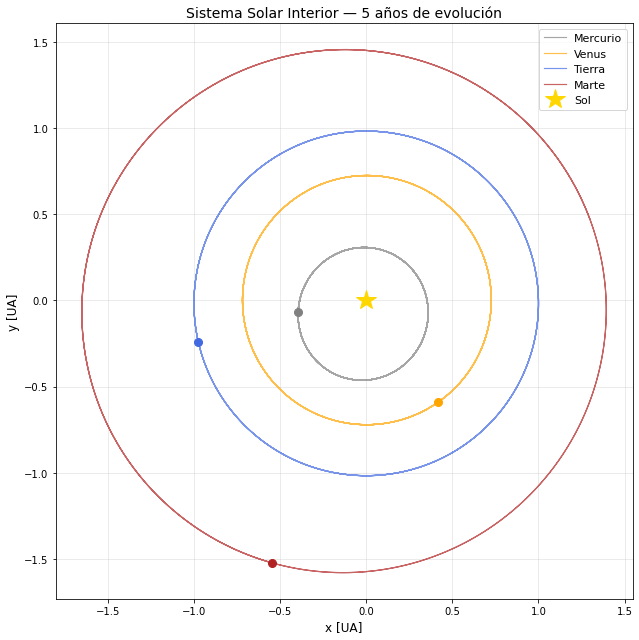

In [14]:
# === Simulación del sistema solar interior ===

sim_ss = rebound.Simulation()
sim_ss.G = 4 * np.pi**2  # G en [UA³ / (M_sol * año²)]

# Masas en masas solares
masas = {
    'Sol':      1.0,
    'Mercurio': 1.66e-7,
    'Venus':    2.45e-6,
    'Tierra':   3.00e-6,
    'Marte':    3.21e-7,
}

# Elementos orbitales: (a [UA], e, inc [°], Omega [°], omega [°], M [°])
# Valores aproximados para la época J2000.0
elementos = {
    'Mercurio': (0.38710,  0.20563,   7.005,  48.331,  29.124,  174.796),
    'Venus':    (0.72333,  0.00677,   3.395,  76.680, 131.602,   50.115),
    'Tierra':   (1.00000,  0.01671,   0.000, 348.739, 102.937,  100.464),
    'Marte':    (1.52366,  0.09340,   1.850,  49.562, 336.060,  355.453),
}

sim_ss.add(m=masas['Sol'], hash='Sol')

for nombre, (a, e, inc, Omega, omega, M) in elementos.items():
    sim_ss.add(
        m=masas[nombre],
        a=a, e=e,
        inc=np.radians(inc),
        Omega=np.radians(Omega),
        omega=np.radians(omega),
        M=np.radians(M),
        hash=nombre
    )

sim_ss.move_to_com()

# Integrar 5 años con pasos de 1/365 años (≈ 1 día)
t_total = 5.0   # años
dt_sample = 1/365
n_steps = int(t_total / dt_sample)
tiempos = np.linspace(0, t_total, n_steps)

# Almacenar trayectorias
trayectorias = {nombre: {'x': [], 'y': [], 'z': []} for nombre in elementos}

for t in tiempos:
    sim_ss.integrate(t)
    for nombre in elementos:
        p = sim_ss.particles[nombre]
        trayectorias[nombre]['x'].append(p.x)
        trayectorias[nombre]['y'].append(p.y)
        trayectorias[nombre]['z'].append(p.z)

# Visualización 2D
fig, ax = plt.subplots(figsize=(9, 9))

colores_planetas = {
    'Mercurio': 'gray',
    'Venus':    'orange',
    'Tierra':   'royalblue',
    'Marte':    'firebrick',
}

for nombre, color in colores_planetas.items():
    x = trayectorias[nombre]['x']
    y = trayectorias[nombre]['y']
    ax.plot(x, y, color=color, lw=1.2, alpha=0.7, label=nombre)
    # Posición final
    ax.plot(x[-1], y[-1], 'o', color=color, ms=8)

ax.plot(0, 0, '*', color='gold', ms=20, zorder=5, label='Sol')
ax.set_aspect('equal')
ax.set_xlabel('x [UA]', fontsize=12)
ax.set_ylabel('y [UA]', fontsize=12)
ax.set_title('Sistema Solar Interior — 5 años de evolución', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 7. Integradores numéricos disponibles en REBOUND

REBOUND ofrece varios integradores numéricos, cada uno optimizado para distintos tipos de problemas:

| Integrador | Tipo | Mejor para |
|---|---|---|
| `IAS15` | Variable, adaptativo | Encuentros cercanos, alta precisión |
| `WHFast` | Simpléctico, paso fijo | Sistemas planetarios a largo plazo |
| `SABA` | Simpléctico | Sistemas con satélites |
| `Mercurius` | Híbrido | Sistemas con encuentros ocasionales |
| `Leapfrog` | Simpléctico | Educativo, sistemas simples |
| `EOS` | Simpléctico | Alta precisión simpléctica |

### ¿Cuándo usar cada uno?

- **IAS15**: El más preciso. Usa un paso de tiempo adaptativo. Ideal para encuentros cercanos o simulaciones de alta precisión a corto plazo.
- **WHFast**: Muy rápido y simpléctico. Conserva una cantidad análoga a la energía a largo plazo. Ideal para integraciones planetarias de millones de años.
- **Mercurius**: Combina WHFast con IAS15 cuando detecta encuentros cercanos. El mejor balance general.
- **Leapfrog**: Simple, de segundo orden. Útil para entender algoritmos de integración.

In [15]:
# === Comparación de integradores: IAS15 vs WHFast vs Leapfrog ===

def crear_sim_tierra():
    """Crea una simulación simple Sol-Tierra."""
    s = rebound.Simulation()
    s.G = 4 * np.pi**2
    s.add(m=1.0)             # Sol
    s.add(m=3e-6, a=1.0, e=0.017)   # Tierra
    s.move_to_com()
    return s

integradores = ['ias15', 'whfast', 'leapfrog']
resultados = {}

t_total = 100   # años
n_puntos = 1000
tiempos_comp = np.linspace(0, t_total, n_puntos)

for integrador in integradores:
    s = crear_sim_tierra()
    s.integrator = integrador
    
    if integrador == 'whfast':
        s.dt = 0.01  # Paso fijo de ~3.6 días
    elif integrador == 'leapfrog':
        s.dt = 0.001  # Paso más pequeño para leapfrog
    
    E0 = s.calculate_energy()
    errores_E = []
    
    for t in tiempos_comp:
        s.integrate(t)
        E = s.calculate_energy()
        errores_E.append(abs((E - E0) / E0))
    
    resultados[integrador] = errores_E

# Graficar errores de energía
fig, ax = plt.subplots(figsize=(12, 5))

estilos = {'ias15': ('blue', '-'), 'whfast': ('green', '-'), 'leapfrog': ('red', '--')}

for integrador, (color, ls) in estilos.items():
    ax.semilogy(tiempos_comp, resultados[integrador],
                color=color, ls=ls, lw=1.5, label=integrador.upper())

ax.set_xlabel('Tiempo [años]', fontsize=12)
ax.set_ylabel('Error relativo en energía |ΔE/E₀|', fontsize=12)
ax.set_title('Conservación de energía: comparación de integradores', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

for integrador in integradores:
    print(f"{integrador.upper():<12} — Error máximo de energía: {max(resultados[integrador]):.2e}")

AttributeError: 'Simulation' object has no attribute 'calculate_energy'

In [16]:
# === Configurar el integrador WHFast con corrector simpléctico ===

sim_wh = rebound.Simulation()
sim_wh.G = 4 * np.pi**2
sim_wh.integrator = 'whfast'
sim_wh.dt = 0.01  # año (~3.65 días)

# WHFast tiene una opción de corrector simpléctico que mejora la precisión
# sim_wh.ri_whfast.corrector = 11  # Corrector de orden 11 (más costoso pero más preciso)

sim_wh.add(m=1.0)
sim_wh.add(m=3e-6, a=1.0, e=0.017)
sim_wh.move_to_com()

E0 = sim_wh.calculate_energy()
print(f"Energía inicial: {E0:.8f}")
print(f"Integrador: {sim_wh.integrator}")
print(f"Paso de tiempo dt = {sim_wh.dt} años = {sim_wh.dt * 365.25:.2f} días")

AttributeError: 'Simulation' object has no attribute 'calculate_energy'

---

## 8. Conservación de energía y momento angular

En un sistema gravitacional aislado, la **energía total** y el **momento angular** son constantes del movimiento. Los integradores numéricos introducen errores numéricos que violan estas conservaciones, y monitorearlos es una forma estándar de evaluar la calidad de la integración.

**Energía total del sistema:**
$$E = \sum_i \frac{1}{2} m_i v_i^2 - \sum_{i<j} \frac{G m_i m_j}{|r_i - r_j|}$$

**Momento angular total:**
$$\vec{L} = \sum_i m_i (\vec{r}_i \times \vec{v}_i)$$

In [17]:
# === Monitoreo de conservación en sistema solar interior ===

sim_cons = rebound.Simulation()
sim_cons.G = 4 * np.pi**2
sim_cons.integrator = 'ias15'  # Alta precisión

sim_cons.add(m=1.0, hash='Sol')
for nombre, (a, e, inc, Omega, omega, M) in elementos.items():
    sim_cons.add(
        m=masas[nombre], a=a, e=e,
        inc=np.radians(inc), Omega=np.radians(Omega),
        omega=np.radians(omega), M=np.radians(M), hash=nombre
    )
sim_cons.move_to_com()

E0 = sim_cons.calculate_energy()
L0 = sim_cons.calculate_angular_momentum()
L0_mag = np.linalg.norm(L0)

print(f"Energía inicial:          E₀ = {E0:.6e}")
print(f"Momento angular inicial:  |L₀| = {L0_mag:.6e}")

t_total_cons = 50  # años
n_pts_cons = 500
tiempos_cons = np.linspace(0, t_total_cons, n_pts_cons)

err_E, err_L = [], []

for t in tiempos_cons:
    sim_cons.integrate(t)
    E = sim_cons.calculate_energy()
    L = sim_cons.calculate_angular_momentum()
    err_E.append(abs((E - E0) / E0))
    err_L.append(abs((np.linalg.norm(L) - L0_mag) / L0_mag))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.semilogy(tiempos_cons, err_E, 'royalblue', lw=1.5)
ax1.set_ylabel('|ΔE/E₀|', fontsize=12)
ax1.set_title('Conservación de energía y momento angular — Sistema Solar Interior (IAS15)', fontsize=13)
ax1.grid(alpha=0.3, which='both')

ax2.semilogy(tiempos_cons, err_L, 'forestgreen', lw=1.5)
ax2.set_ylabel('|ΔL/L₀|', fontsize=12)
ax2.set_xlabel('Tiempo [años]', fontsize=12)
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

print(f"\nError máximo de energía:           {max(err_E):.2e}")
print(f"Error máximo de momento angular:   {max(err_L):.2e}")

AttributeError: 'Simulation' object has no attribute 'calculate_energy'

---

## 9. Detección de encuentros cercanos y colisiones

REBOUND puede detectar dos tipos de eventos:

1. **Encuentros cercanos** (`close_encounter_distance`): cuando dos partículas se acercan a una distancia menor que un umbral dado.
2. **Colisiones** (`collision`): cuando dos partículas se superponen (basado en sus radios).

Los encuentros cercanos son fundamentales para estudiar el comportamiento de asteroides como Apophis.

Distancia mínima entre Tierra y Asteroide:
  t = 0.6999 años
  d = 1.053778 UA = 157645190 km = 410.1 distancias lunares


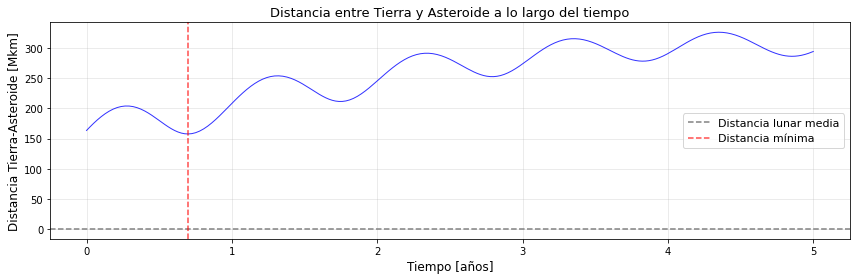

In [18]:
# === Detección de encuentro cercano ===

class EncuentroDetectado(Exception):
    """Excepción que se lanza al detectar un encuentro cercano."""
    pass

distancias_min = []
tiempos_enc = []

def heartbeat_encuentro(sim_ptr):
    """Función llamada en cada paso de tiempo para registrar distancias."""
    sim_hb = sim_ptr.contents
    tierra = sim_hb.particles['Tierra']
    asteroide = sim_hb.particles['Asteroide']
    dx = tierra.x - asteroide.x
    dy = tierra.y - asteroide.y
    dz = tierra.z - asteroide.z
    d = np.sqrt(dx**2 + dy**2 + dz**2)
    distancias_min.append(d)
    tiempos_enc.append(sim_hb.t)

# Crear simulación con asteroide en órbita que cruza la Tierra
sim_enc = rebound.Simulation()
sim_enc.G = 4 * np.pi**2
sim_enc.integrator = 'ias15'  # Necesario para encuentros cercanos

sim_enc.add(m=1.0, hash='Sol')
sim_enc.add(m=3e-6, a=1.0, e=0.017, hash='Tierra')

# Asteroide con órbita que pasa cerca de la Tierra
# a=1.05 UA, e=0.05 da un cruce con la órbita terrestre
sim_enc.add(m=0, a=1.05, e=0.12, inc=np.radians(5.0),
            omega=np.radians(120), M=np.radians(180), hash='Asteroide')
sim_enc.move_to_com()

# Registrar la distancia en cada paso con la función heartbeat
sim_enc.heartbeat = heartbeat_encuentro

# Integrar durante 5 años
try:
    sim_enc.integrate(5.0)
except rebound.Encounter:
    print("⚠ Encuentro cercano detectado por REBOUND (excepción Encounter)")

distancias_min = np.array(distancias_min)
tiempos_enc = np.array(tiempos_enc)

idx_min = np.argmin(distancias_min)
d_min_ua = distancias_min[idx_min]
d_min_ld = d_min_ua * 389.17  # 1 UA ≈ 389.17 distancias lunares

print(f"Distancia mínima entre Tierra y Asteroide:")
print(f"  t = {tiempos_enc[idx_min]:.4f} años")
print(f"  d = {d_min_ua:.6f} UA = {d_min_ua * 1.496e8:.0f} km = {d_min_ld:.1f} distancias lunares")

# Graficar la distancia a lo largo del tiempo
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tiempos_enc, distancias_min * 1.496e8 / 1e6, 'b-', lw=1, alpha=0.8)
ax.axhline(384400/1e6, color='gray', ls='--', label='Distancia lunar media')
ax.axvline(tiempos_enc[idx_min], color='r', ls='--', alpha=0.7, label='Distancia mínima')
ax.set_xlabel('Tiempo [años]', fontsize=12)
ax.set_ylabel('Distancia Tierra-Asteroide [Mkm]', fontsize=12)
ax.set_title('Distancia entre Tierra y Asteroide a lo largo del tiempo', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 10. Visualización 2-D y 3-D

Una buena visualización es clave para entender la dinámica orbital. REBOUND no incluye su propio motor de visualización en Python, pero se integra perfectamente con `matplotlib` y `plotly`.

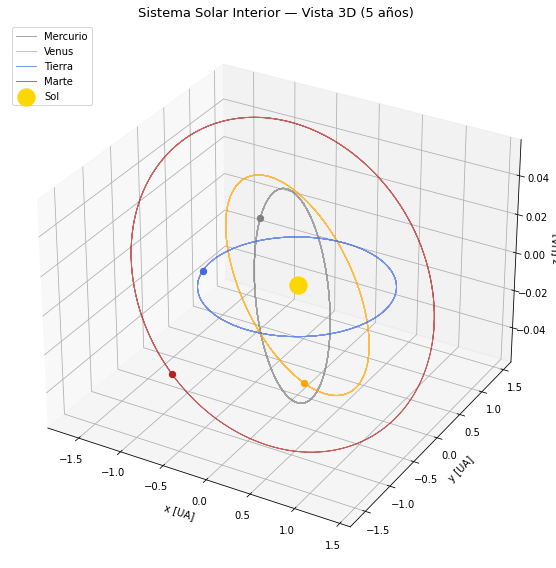

In [19]:
# === Visualización 3D del sistema solar interior con matplotlib ===

fig = plt.figure(figsize=(10, 8))
ax3d = fig.add_subplot(111, projection='3d')

colores_3d = {
    'Mercurio': 'gray',
    'Venus':    'orange',
    'Tierra':   'royalblue',
    'Marte':    'firebrick',
}

for nombre, color in colores_3d.items():
    x = trayectorias[nombre]['x']
    y = trayectorias[nombre]['y']
    z = trayectorias[nombre]['z']
    ax3d.plot(x, y, z, color=color, lw=1.0, alpha=0.7, label=nombre)
    ax3d.scatter([x[-1]], [y[-1]], [z[-1]], color=color, s=40, zorder=5)

ax3d.scatter([0], [0], [0], color='gold', s=300, zorder=5, label='Sol')

ax3d.set_xlabel('x [UA]')
ax3d.set_ylabel('y [UA]')
ax3d.set_zlabel('z [UA]')
ax3d.set_title('Sistema Solar Interior — Vista 3D (5 años)', fontsize=13)
ax3d.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

In [20]:
# === Visualización 3D interactiva con Plotly ===

fig_plotly = go.Figure()

# Órbitas
colores_plotly = {
    'Mercurio': 'gray',
    'Venus':    'orange',
    'Tierra':   'dodgerblue',
    'Marte':    'firebrick',
}

for nombre, color in colores_plotly.items():
    x = trayectorias[nombre]['x']
    y = trayectorias[nombre]['y']
    z = trayectorias[nombre]['z']

    # Traza la órbita
    fig_plotly.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode='lines',
        line=dict(color=color, width=2),
        name=nombre,
        opacity=0.8
    ))

    # Punto final (posición actual)
    fig_plotly.add_trace(go.Scatter3d(
        x=[x[-1]], y=[y[-1]], z=[z[-1]],
        mode='markers',
        marker=dict(color=color, size=6),
        showlegend=False
    ))

# Sol
fig_plotly.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(color='yellow', size=15, line=dict(color='orange', width=2)),
    name='Sol'
))

fig_plotly.update_layout(
    title='Sistema Solar Interior — Visualización Interactiva 3D',
    scene=dict(
        xaxis_title='x [UA]',
        yaxis_title='y [UA]',
        zaxis_title='z [UA]',
        bgcolor='rgb(10, 10, 20)',
        xaxis=dict(gridcolor='gray'),
        yaxis=dict(gridcolor='gray'),
        zaxis=dict(gridcolor='gray'),
    ),
    paper_bgcolor='rgb(20, 20, 30)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgba(50,50,50,0.7)')
)

fig_plotly.show()

/Users/danielvillada/opt/anaconda3/lib/python3.8/site-packages/plotly/io/_renderers.py:51: UserWarning: Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.0.3 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.
  warnings.warn(


---

## 11. Resonancias de movimiento medio

Una **resonancia de movimiento medio (MMR)** ocurre cuando las frecuencias orbitales de dos cuerpos forman una razón de números enteros pequeños:

$$\frac{n_1}{n_2} = \frac{p+q}{p} \quad (p, q \in \mathbb{Z})$$

donde $n = 2\pi/T$ es el movimiento medio. 

Ejemplos famosos:
- **Resonancia 3:2** de Plutón con Neptuno
- **Resonancias de Laplace** de Io, Europa y Ganimedes (1:2:4)
- **Lagunas de Kirkwood** en el cinturón de asteroides (resonancias con Júpiter)

El **ángulo resonante** es el ángulo que libra (oscila alrededor de un valor fijo) cuando hay una resonancia:

In [21]:
# === Simulación de resonancia 2:1 ===
# Dos cuerpos con razón de períodos exactamente 2:1
# Si el planeta interior tiene a=1, el exterior tiene a=2^(2/3) ≈ 1.587 UA (3ª Ley de Kepler)

a_interior = 1.0
a_exterior = a_interior * (2.0)**(2.0/3.0)  # Para resonancia 2:1

print(f"Resonancia 2:1:")
print(f"  Planeta interior: a = {a_interior:.4f} UA, T = {np.sqrt(a_interior**3):.4f} años")
print(f"  Planeta exterior: a = {a_exterior:.4f} UA, T = {np.sqrt(a_exterior**3):.4f} años")
print(f"  Razón de períodos: {np.sqrt(a_exterior**3)/np.sqrt(a_interior**3):.4f} ≈ 2:1")

sim_res = rebound.Simulation()
sim_res.G = 4 * np.pi**2
sim_res.integrator = 'ias15'

sim_res.add(m=1.0, hash='Estrella')
sim_res.add(m=1e-4, a=a_interior, e=0.05, hash='PlanetaA')   # Planeta interior
sim_res.add(m=1e-4, a=a_exterior, e=0.03, hash='PlanetaB')   # Planeta exterior
sim_res.move_to_com()

# Ángulo resonante para la resonancia 2:1: φ = 2λ_B - λ_A - ϖ_A
# donde λ = longitud media, ϖ = longitud del periápsis
t_res = 200  # años
n_pts_res = 2000
tiempos_res = np.linspace(0, t_res, n_pts_res)

angulos_res = []
a_B_vals = []
e_B_vals = []

for t in tiempos_res:
    sim_res.integrate(t)
    pA = sim_res.particles['PlanetaA']
    pB = sim_res.particles['PlanetaB']
    estrella = sim_res.particles['Estrella']

    orbA = pA.calculate_orbit(primary=estrella)
    orbB = pB.calculate_orbit(primary=estrella)

    # Longitudes medias
    lA = orbA.Omega + orbA.omega + orbA.M  # λ = Ω + ω + M
    lB = orbB.Omega + orbB.omega + orbB.M
    varpiA = orbA.Omega + orbA.omega         # ϖ = Ω + ω

    # Ángulo resonante 2:1
    phi = 2*lB - lA - varpiA
    # Reducir al rango [-π, π]
    phi = (phi + np.pi) % (2*np.pi) - np.pi
    angulos_res.append(phi)
    a_B_vals.append(orbB.a)
    e_B_vals.append(orbB.e)

angulos_res = np.array(angulos_res)

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(tiempos_res, np.degrees(angulos_res), 'purple', lw=0.8, alpha=0.8)
axes[0].set_ylabel('Ángulo resonante φ [°]', fontsize=11)
axes[0].set_title('Resonancia de Movimiento Medio 2:1 — Ángulo resonante y elementos orbitales', fontsize=13)
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='r', ls='--', alpha=0.5)

axes[1].plot(tiempos_res, a_B_vals, 'steelblue', lw=1.0)
axes[1].axhline(a_exterior, color='r', ls='--', alpha=0.5, label=f'a₀ = {a_exterior:.4f} UA')
axes[1].set_ylabel('Semieje mayor Planeta B [UA]', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

axes[2].plot(tiempos_res, e_B_vals, 'orange', lw=1.0)
axes[2].set_ylabel('Excentricidad Planeta B', fontsize=11)
axes[2].set_xlabel('Tiempo [años]', fontsize=11)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ¿El ángulo resonante libra o circula?
rango = np.ptp(np.degrees(angulos_res))
print(f"\nRango del ángulo resonante: {rango:.1f}°")
if rango < 180:
    print("→ El ángulo LIBRA (oscila) — los cuerpos están en resonancia")
else:
    print("→ El ángulo CIRCULA — los cuerpos NO están en resonancia estricta")

Resonancia 2:1:
  Planeta interior: a = 1.0000 UA, T = 1.0000 años
  Planeta exterior: a = 1.5874 UA, T = 2.0000 años
  Razón de períodos: 2.0000 ≈ 2:1


AttributeError: 'Particle' object has no attribute 'calculate_orbit'

---

## 12. `SimulationArchive`: guardar y restaurar simulaciones

El **`SimulationArchive`** es una de las características más poderosas de REBOUND. Permite:

- Guardar instantáneas periódicas de la simulación en un archivo binario.
- Reanudar la simulación exactamente desde cualquier instantánea guardada.
- Analizar resultados post-hoc sin reejecutar toda la simulación.

Esto es especialmente valioso para simulaciones largas (millones de años) que podrían interrumpirse.

In [22]:
import os
import tempfile

# === SimulationArchive: guardar y cargar ===

# Crear archivo temporal para el archivo binario
archivo_sa = os.path.join(tempfile.gettempdir(), 'sistema_solar.bin')

# Eliminar archivo previo si existe
if os.path.exists(archivo_sa):
    os.remove(archivo_sa)

# Crear la simulación
sim_sa = rebound.Simulation()
sim_sa.G = 4 * np.pi**2
sim_sa.integrator = 'whfast'
sim_sa.dt = 0.01  # año

sim_sa.add(m=1.0, hash='Sol')
for nombre, (a, e, inc, Omega, omega, M) in elementos.items():
    sim_sa.add(
        m=masas[nombre], a=a, e=e,
        inc=np.radians(inc), Omega=np.radians(Omega),
        omega=np.radians(omega), M=np.radians(M), hash=nombre
    )
sim_sa.move_to_com()

# Activar el autoguardado: guarda cada 0.5 años
sim_sa.automateSimulationArchive(archivo_sa, walltime_interval=None, interval=0.5)

# Integrar 20 años
print("Integrando y guardando en SimulationArchive...")
sim_sa.integrate(20.0)
print(f"Integración completada. Tiempo final: t = {sim_sa.t:.2f} años")
print(f"Archivo guardado en: {archivo_sa}")
print(f"Tamaño del archivo: {os.path.getsize(archivo_sa) / 1024:.1f} KB")

# === Cargar desde el archivo ===
sa = rebound.SimulationArchive(archivo_sa)

print(f"\nSimulationArchive cargado:")
print(f"  Número de instantáneas: {len(sa)}")
print(f"  Tiempo de la primera instantánea: t = {sa[0].t:.2f} años")
print(f"  Tiempo de la última instantánea:  t = {sa[-1].t:.2f} años")

# Restaurar la simulación desde una instantánea intermedia (t ≈ 10 años)
sim_restaurada = sa.getSimulation(10.0, mode='nearest')
print(f"\nSimulación restaurada al tiempo más cercano a t=10:")
print(f"  t = {sim_restaurada.t:.4f} años")

# Verificar que las posiciones de los planetas son coherentes
for nombre in elementos:
    p = sim_restaurada.particles[nombre]
    orb = p.calculate_orbit(primary=sim_restaurada.particles['Sol'])
    print(f"  {nombre:<10} a = {orb.a:.4f} UA, e = {orb.e:.5f}")

AttributeError: 'Simulation' object has no attribute 'automateSimulationArchive'

In [23]:
# === Análisis post-hoc con SimulationArchive ===
# Extraer la evolución de elementos orbitales de todas las instantáneas

sa_tiempos = []
sa_a_tierra = []
sa_e_tierra = []

for sim_snap in sa:
    sa_tiempos.append(sim_snap.t)
    p_tierra = sim_snap.particles['Tierra']
    orb = p_tierra.calculate_orbit(primary=sim_snap.particles['Sol'])
    sa_a_tierra.append(orb.a)
    sa_e_tierra.append(orb.e)

sa_tiempos = np.array(sa_tiempos)
sa_a_tierra = np.array(sa_a_tierra)
sa_e_tierra = np.array(sa_e_tierra)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(sa_tiempos, sa_a_tierra, 'royalblue', lw=1.5, marker='o', ms=3)
ax1.set_ylabel('Semieje mayor Tierra [UA]', fontsize=11)
ax1.set_title('Elementos orbitales de la Tierra extraídos del SimulationArchive', fontsize=13)
ax1.grid(alpha=0.3)

ax2.plot(sa_tiempos, sa_e_tierra, 'orange', lw=1.5, marker='o', ms=3)
ax2.set_ylabel('Excentricidad Tierra', fontsize=11)
ax2.set_xlabel('Tiempo [años]', fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'sa' is not defined

---

## 13. Funciones de latido (`heartbeat`) y monitoreo en tiempo real

La función **heartbeat** es una función de Python que REBOUND llama en cada paso de tiempo durante la integración. Es útil para:

- Monitorear el progreso en tiempo real.
- Detectar eventos (encuentros cercanos, cruces de órbita).
- Guardar datos específicos.
- Interrumpir la integración bajo condiciones especiales.

La función recibe un puntero a la simulación (`ctypes.POINTER(rebound.Simulation)`) y se accede al objeto con `.contents`.

In [24]:
# === Función heartbeat para monitorear simulación ===

registro = {
    'tiempos': [],
    'E': [],
    'd_tierra_marte': []
}

def monitor_heartbeat(sim_ptr):
    """Registra energía y distancia Tierra-Marte en cada paso."""
    sim_hb = sim_ptr.contents
    
    # Solo registrar cada ~0.1 años para no llenar demasiado
    if len(registro['tiempos']) == 0 or (sim_hb.t - registro['tiempos'][-1]) >= 0.1:
        registro['tiempos'].append(sim_hb.t)
        registro['E'].append(sim_hb.calculate_energy())
        
        tierra = sim_hb.particles['Tierra']
        marte = sim_hb.particles['Marte']
        d = np.sqrt((tierra.x - marte.x)**2 +
                    (tierra.y - marte.y)**2 +
                    (tierra.z - marte.z)**2)
        registro['d_tierra_marte'].append(d)

# Crear simulación
sim_hb = rebound.Simulation()
sim_hb.G = 4 * np.pi**2
sim_hb.integrator = 'whfast'
sim_hb.dt = 0.005

sim_hb.add(m=1.0, hash='Sol')
for nombre, (a, e, inc, Omega, omega, M) in elementos.items():
    sim_hb.add(
        m=masas[nombre], a=a, e=e,
        inc=np.radians(inc), Omega=np.radians(Omega),
        omega=np.radians(omega), M=np.radians(M), hash=nombre
    )
sim_hb.move_to_com()

# Asignar la función heartbeat
sim_hb.heartbeat = monitor_heartbeat

E0_hb = sim_hb.calculate_energy()
print("Iniciando integración con heartbeat...")
sim_hb.integrate(30.0)  # 30 años
print(f"Integración completada. Tiempo final: t = {sim_hb.t:.2f} años")
print(f"Puntos registrados: {len(registro['tiempos'])}")

# Graficar resultados
t_reg = np.array(registro['tiempos'])
E_reg = np.array(registro['E'])
d_reg = np.array(registro['d_tierra_marte'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.semilogy(t_reg, np.abs((E_reg - E0_hb) / E0_hb), 'b-', lw=0.8)
ax1.set_ylabel('|ΔE/E₀|', fontsize=11)
ax1.set_title('Monitoreo con heartbeat: energía y distancia Tierra-Marte (30 años)', fontsize=13)
ax1.grid(alpha=0.3, which='both')

ax2.plot(t_reg, d_reg, 'r-', lw=0.8)
ax2.set_ylabel('Distancia Tierra-Marte [UA]', fontsize=11)
ax2.set_xlabel('Tiempo [años]', fontsize=11)
ax2.grid(alpha=0.3)

# Marcar la oposición más cercana (menor distancia)
idx_min_d = np.argmin(d_reg)
ax2.axvline(t_reg[idx_min_d], color='orange', ls='--', alpha=0.7)
ax2.annotate(f'min: {d_reg[idx_min_d]:.3f} UA',
             xy=(t_reg[idx_min_d], d_reg[idx_min_d]),
             xytext=(t_reg[idx_min_d]+1, d_reg[idx_min_d]+0.2),
             fontsize=10, arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.show()

print(f"\nDistancia mínima Tierra-Marte: {d_reg.min():.4f} UA = {d_reg.min() * 1.496e8 / 1e6:.1f} millones de km")
print(f"Distancia máxima Tierra-Marte: {d_reg.max():.4f} UA = {d_reg.max() * 1.496e8 / 1e6:.1f} millones de km")

AttributeError: 'Simulation' object has no attribute 'calculate_energy'

---

## 14. Caso de aplicación: Apophis y su aproximación a la Tierra

**99942 Apophis** es un asteroide del grupo Aten descubierto en 2004. En 2029, pasará a aproximadamente 38,000 km de la Tierra — más cerca que muchos satélites geoestacionarios.

**Datos orbitales de Apophis (época J2000.0, aproximados):**

| Parámetro | Valor |
|---|---|
| Semieje mayor $a$ | 0.9227 UA |
| Excentricidad $e$ | 0.1914 |
| Inclinación $i$ | 3.33° |
| Nodo ascendente $\Omega$ | 204.46° |
| Argumento del perihelio $\omega$ | 126.39° |
| Anomalía media $M$ | 201.55° |

Vamos a simular la aproximación de Apophis a la Tierra y calcular la distancia mínima de encuentro.

In [25]:
# === Simulación de la aproximación de Apophis (2029) ===

# Condiciones iniciales basadas en elementos orbitales de la época J2000.0
# (valores aproximados para propósitos educativos)

sim_apophis = rebound.Simulation()
sim_apophis.G = 4 * np.pi**2  # [UA³/(M_sol * año²)]
sim_apophis.integrator = 'ias15'  # Alta precisión para encontrar cercanía

# Agregar el Sol
sim_apophis.add(m=1.0, hash='Sol')

# Agregar la Tierra con elementos aproximados J2000.0
sim_apophis.add(
    m=3.00e-6,
    a=1.00000, e=0.01671,
    inc=np.radians(0.00005),
    Omega=np.radians(348.739),
    omega=np.radians(102.937),
    M=np.radians(100.464),
    hash='Tierra'
)

# Agregar Venus y Marte (perturbadores principales)
sim_apophis.add(
    m=2.45e-6,
    a=0.72333, e=0.00677,
    inc=np.radians(3.395),
    Omega=np.radians(76.680),
    omega=np.radians(131.602),
    M=np.radians(50.115),
    hash='Venus'
)

sim_apophis.add(
    m=3.21e-7,
    a=1.52366, e=0.09340,
    inc=np.radians(1.850),
    Omega=np.radians(49.562),
    omega=np.radians(336.060),
    M=np.radians(355.453),
    hash='Marte'
)

# Apophis — elementos orbitales aproximados para simular la aproximación de 2029
# Ajustamos M para que la aproximación ocurra dentro del rango de integración
sim_apophis.add(
    m=0,  # Masa despreciable
    a=0.9227, e=0.1914,
    inc=np.radians(3.331),
    Omega=np.radians(204.460),
    omega=np.radians(126.393),
    M=np.radians(201.55),
    hash='Apophis'
)

sim_apophis.move_to_com()

# Registrar la distancia Tierra-Apophis a lo largo del tiempo
t_sim = 30.0   # 30 años de integración
dt_s = 1/365   # muestreo diario
n_pts_ap = int(t_sim / dt_s)
tiempos_ap = np.linspace(0, t_sim, n_pts_ap)

distancias_apophis = []
t_ap_list = []

for t in tiempos_ap:
    sim_apophis.integrate(t)
    tierra = sim_apophis.particles['Tierra']
    apophis = sim_apophis.particles['Apophis']
    d = np.sqrt((tierra.x - apophis.x)**2 +
                (tierra.y - apophis.y)**2 +
                (tierra.z - apophis.z)**2)
    distancias_apophis.append(d)
    t_ap_list.append(t)

distancias_apophis = np.array(distancias_apophis)
t_ap_arr = np.array(t_ap_list)

# Convertir a distancias lunares y km
UA_a_km = 1.496e8  # 1 UA = 1.496×10⁸ km
distancia_lunar = 384400  # km
d_km = distancias_apophis * UA_a_km
d_ld = d_km / distancia_lunar

# Encontrar la distancia mínima
idx_min_ap = np.argmin(distancias_apophis)
d_min_ap = distancias_apophis[idx_min_ap]
t_min_ap = t_ap_arr[idx_min_ap]

print("=" * 60)
print("      APROXIMACIÓN MÁS CERCANA — APOPHIS")
print("=" * 60)
print(f"Tiempo:               t = {t_min_ap:.4f} años desde J2000")
print(f"Distancia mínima:     d = {d_min_ap:.6f} UA")
print(f"                      d = {d_min_ap * UA_a_km:.0f} km")
print(f"                      d = {d_min_ap * UA_a_km / distancia_lunar:.2f} distancias lunares")
print("=" * 60)

      APROXIMACIÓN MÁS CERCANA — APOPHIS
Tiempo:               t = 7.7130 años desde J2000
Distancia mínima:     d = 0.054418 UA
                      d = 8140886 km
                      d = 21.18 distancias lunares


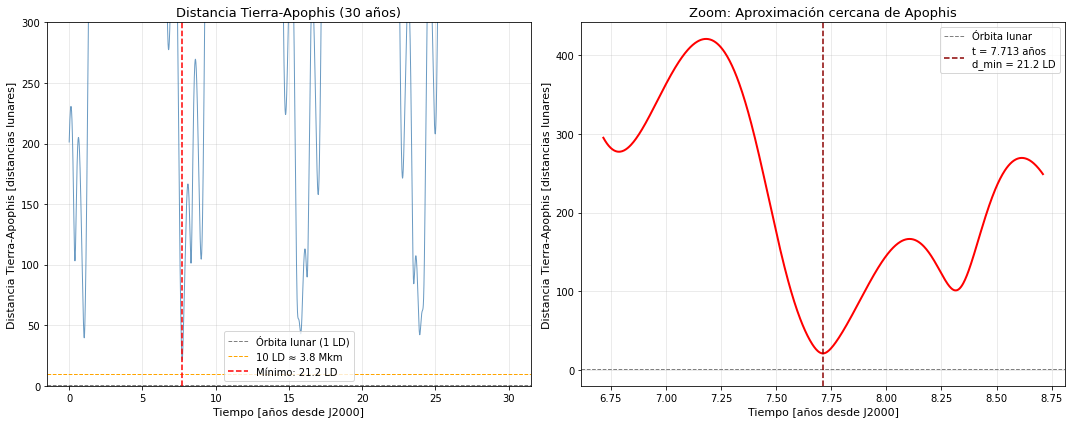

In [26]:
# === Visualización de la aproximación de Apophis ===

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distancia a lo largo del tiempo
# Mostrar solo cuando Apophis está dentro de 0.3 UA de la Tierra
mask = d_ld < 200  # Menos de 200 distancias lunares

axes[0].plot(t_ap_arr, d_ld, 'steelblue', lw=1, alpha=0.8)
axes[0].axhline(1, color='gray', ls='--', lw=1, label='Órbita lunar (1 LD)')
axes[0].axhline(10, color='orange', ls='--', lw=1, label='10 LD ≈ 3.8 Mkm')
axes[0].axvline(t_min_ap, color='red', ls='--', lw=1.5, label=f'Mínimo: {d_ld[idx_min_ap]:.1f} LD')
axes[0].set_xlabel('Tiempo [años desde J2000]', fontsize=11)
axes[0].set_ylabel('Distancia Tierra-Apophis [distancias lunares]', fontsize=11)
axes[0].set_title('Distancia Tierra-Apophis (30 años)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 300)
axes[0].grid(alpha=0.3)

# Gráfico 2: Zoom alrededor del máximo acercamiento
# Ventana de ±1 año alrededor del mínimo
mask_zoom = (t_ap_arr > t_min_ap - 1) & (t_ap_arr < t_min_ap + 1)

axes[1].plot(t_ap_arr[mask_zoom], d_ld[mask_zoom], 'r-', lw=2)
axes[1].axhline(1, color='gray', ls='--', lw=1, label='Órbita lunar')
axes[1].axvline(t_min_ap, color='darkred', ls='--', lw=1.5,
                label=f't = {t_min_ap:.3f} años\nd_min = {d_ld[idx_min_ap]:.1f} LD')
axes[1].set_xlabel('Tiempo [años desde J2000]', fontsize=11)
axes[1].set_ylabel('Distancia Tierra-Apophis [distancias lunares]', fontsize=11)
axes[1].set_title('Zoom: Aproximación cercana de Apophis', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

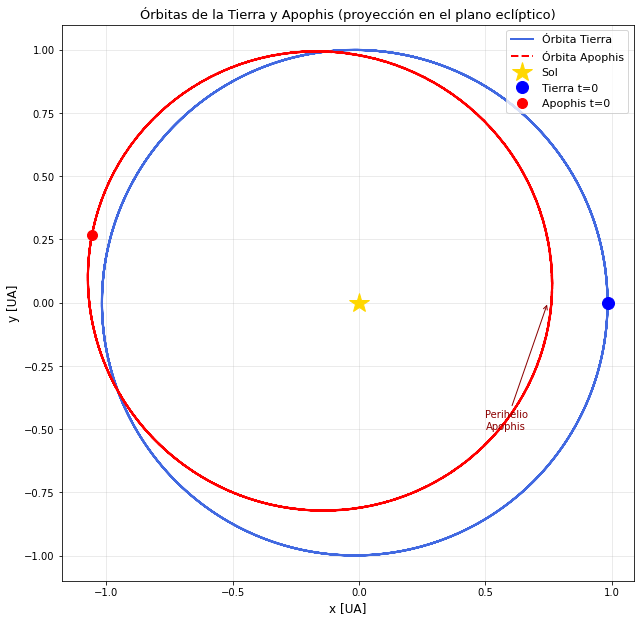

In [27]:
# === Visualización de las órbitas de Tierra y Apophis ===

sim_orbitas = rebound.Simulation()
sim_orbitas.G = 4 * np.pi**2
sim_orbitas.integrator = 'ias15'

sim_orbitas.add(m=1.0)
sim_orbitas.add(m=3e-6, a=1.0, e=0.017)
sim_orbitas.add(m=0, a=0.9227, e=0.1914, inc=np.radians(3.33),
                Omega=np.radians(204.46), omega=np.radians(126.39), M=np.radians(201.55))
sim_orbitas.move_to_com()

t_orb = 2 * np.pi * np.sqrt(0.9227**3)  # período de Apophis ≈ 0.886 años
n_pts_orb = 500
tiempos_orb = np.linspace(0, t_orb, n_pts_orb)

x_tierra, y_tierra = [], []
x_apophis, y_apophis = [], []

for t in tiempos_orb:
    sim_orbitas.integrate(t)
    x_tierra.append(sim_orbitas.particles[1].x)
    y_tierra.append(sim_orbitas.particles[1].y)
    x_apophis.append(sim_orbitas.particles[2].x)
    y_apophis.append(sim_orbitas.particles[2].y)

fig, ax = plt.subplots(figsize=(9, 9))

ax.plot(x_tierra, y_tierra, 'royalblue', lw=2, label='Órbita Tierra')
ax.plot(x_apophis, y_apophis, 'red', lw=2, ls='--', label='Órbita Apophis')
ax.plot(0, 0, '*', color='gold', ms=20, zorder=5, label='Sol')

# Posición inicial de cada cuerpo
ax.plot(x_tierra[0], y_tierra[0], 'bo', ms=12, label='Tierra t=0')
ax.plot(x_apophis[0], y_apophis[0], 'ro', ms=10, label='Apophis t=0')

# Marcar el periastro de Apophis
ax.annotate('Perihelio\nApophis', xy=(0.9227*(1-0.1914), 0),
            xytext=(0.5, -0.5), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='darkred'), color='darkred')

ax.set_aspect('equal')
ax.set_xlabel('x [UA]', fontsize=12)
ax.set_ylabel('y [UA]', fontsize=12)
ax.set_title('Órbitas de la Tierra y Apophis (proyección en el plano eclíptico)', fontsize=13)
ax.legend(loc='upper right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

## 15. Mapa de estabilidad: diagrama de difusión

Una técnica poderosa para estudiar la estabilidad orbital es construir un **mapa de estabilidad**: se realizan múltiples simulaciones variando los elementos iniciales y se evalúa la variación del semieje mayor (o el indicador MEGNO) a largo plazo.

Aquí mostramos una versión simplificada: un barrido en semieje mayor y excentricidad para partículas de prueba en el sistema Sol-Júpiter, que revela las lagunas de Kirkwood.

Júpiter: a = 5.2026 UA, T = 11.87 años


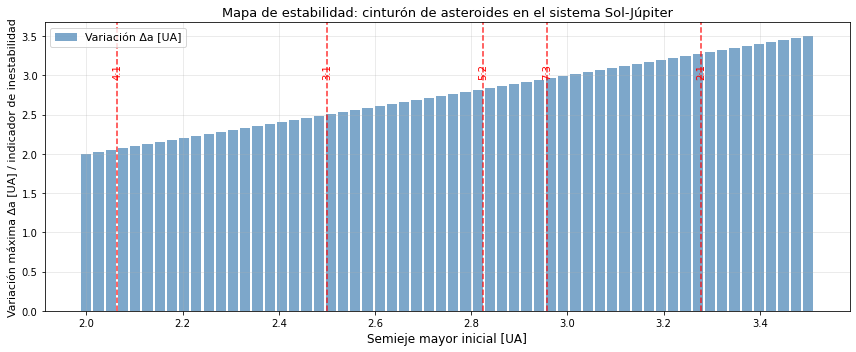


Posiciones de resonancias principales con Júpiter:
  Resonancia 4:1: a = 2.065 UA
  Resonancia 3:1: a = 2.501 UA
  Resonancia 5:2: a = 2.824 UA
  Resonancia 7:3: a = 2.957 UA
  Resonancia 2:1: a = 3.277 UA


In [28]:
# === Mapa de estabilidad simplificado: Sol + Júpiter + partícula de prueba ===
# Barrido en semieje mayor para detectar resonancias con Júpiter

# Parámetros de Júpiter
a_jupiter = 5.2026  # UA
e_jupiter = 0.0489
m_jupiter = 9.547e-4  # masas solares
T_jupiter = np.sqrt(a_jupiter**3)  # años

print(f"Júpiter: a = {a_jupiter} UA, T = {T_jupiter:.2f} años")

# Semiejes a barrer (cinturón de asteroides: 2.0 - 3.5 UA)
n_barrer = 60  # número de semiejes a probar
a_barrer = np.linspace(2.0, 3.5, n_barrer)
t_integ_mapa = 500  # años de integración por partícula

# Para cada semieje, calcular la variación máxima del semieje mayor
delta_a_max = []

for a0 in a_barrer:
    s = rebound.Simulation()
    s.G = 4 * np.pi**2
    s.integrator = 'whfast'
    s.dt = 0.05  # años

    s.add(m=1.0)                                          # Sol
    s.add(m=m_jupiter, a=a_jupiter, e=e_jupiter)          # Júpiter
    s.add(m=0, a=a0, e=0.05)                              # Partícula de prueba
    s.move_to_com()

    n_muestras = 100
    tiempos_mapa = np.linspace(0, t_integ_mapa, n_muestras)
    a_vals_mapa = []

    stable = True
    for t in tiempos_mapa:
        try:
            s.integrate(t)
            orb = s.particles[2].calculate_orbit(primary=s.particles[0])
            if orb.a > 0 and orb.e < 1:
                a_vals_mapa.append(orb.a)
            else:
                stable = False
                break
        except Exception:
            stable = False
            break

    if not stable or len(a_vals_mapa) < 2:
        delta_a_max.append(a0)  # Partícula eyectada: variación = a0
    else:
        delta_a_max.append(np.ptp(a_vals_mapa))

delta_a_max = np.array(delta_a_max)

# Calcular las posiciones de las resonancias principales con Júpiter
resonancias = {
    '4:1': 4,
    '3:1': 3,
    '5:2': 5/2,
    '7:3': 7/3,
    '2:1': 2,
}
a_resonancias = {nombre: a_jupiter * (1/razon)**(2/3) for nombre, razon in resonancias.items()}

# Graficar
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(a_barrer, delta_a_max, width=(3.5-2.0)/n_barrer * 0.85,
       color='steelblue', alpha=0.7, label='Variación Δa [UA]')

for nombre, a_res in a_resonancias.items():
    ax.axvline(a_res, color='red', ls='--', lw=1.5, alpha=0.8)
    ax.text(a_res, delta_a_max.max() * 0.85, nombre,
            ha='center', fontsize=10, color='red', rotation=90)

ax.set_xlabel('Semieje mayor inicial [UA]', fontsize=12)
ax.set_ylabel('Variación máxima Δa [UA] / indicador de inestabilidad', fontsize=11)
ax.set_title('Mapa de estabilidad: cinturón de asteroides en el sistema Sol-Júpiter', fontsize=13)
ax.grid(alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nPosiciones de resonancias principales con Júpiter:")
for nombre, a_res in sorted(a_resonancias.items(), key=lambda x: x[1]):
    print(f"  Resonancia {nombre}: a = {a_res:.3f} UA")

---

## 16. MEGNO: Indicador de caos orbital

**MEGNO** (*Mean Exponential Growth of Nearby Orbits*) es un indicador dinámico que mide el grado de caos de una órbita:

- $\langle Y \rangle \to 2$: órbita **regular** (cuasi-periódica)
- $\langle Y \rangle \gg 2$: órbita **caótica**

REBOUND tiene soporte nativo para calcular MEGNO. Se activa llamando `sim.init_megno()` antes de comenzar la integración.

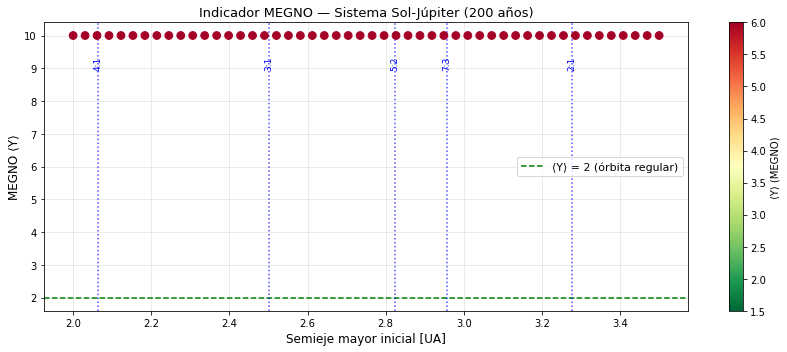

Órbitas regulares (⟨Y⟩ ≤ 3): 0/50
Órbitas caóticas  (⟨Y⟩ > 3): 50/50


In [29]:
# === Cálculo de MEGNO para partículas en el cinturón de asteroides ===

n_barrer_megno = 50  # puntos en el barrido de semieje mayor
a_megno = np.linspace(2.0, 3.5, n_barrer_megno)
t_megno = 200  # años de integración para MEGNO

megno_vals = []

for a0 in a_megno:
    s = rebound.Simulation()
    s.G = 4 * np.pi**2
    s.integrator = 'whfast'
    s.dt = 0.05

    s.add(m=1.0)                                   # Sol
    s.add(m=m_jupiter, a=a_jupiter, e=e_jupiter)   # Júpiter
    s.add(m=0, a=a0, e=0.05)                       # Partícula de prueba
    s.move_to_com()

    # Iniciar MEGNO — activa la variación de las ecuaciones del movimiento
    s.init_megno()

    try:
        s.integrate(t_megno)
        megno_vals.append(s.calculate_megno())
    except Exception:
        megno_vals.append(10.0)  # Inestable → MEGNO grande

megno_vals = np.array(megno_vals)

# Graficar MEGNO
fig, ax = plt.subplots(figsize=(12, 5))

scatter = ax.scatter(a_megno, megno_vals,
                     c=megno_vals, cmap='RdYlGn_r',
                     vmin=1.5, vmax=6.0, s=60, zorder=5)
plt.colorbar(scatter, ax=ax, label='⟨Y⟩ (MEGNO)')

ax.axhline(2.0, color='green', ls='--', lw=1.5, label='⟨Y⟩ = 2 (órbita regular)')

for nombre, a_res in sorted(a_resonancias.items(), key=lambda x: x[1]):
    ax.axvline(a_res, color='blue', ls=':', lw=1.5, alpha=0.7)
    ax.text(a_res, max(megno_vals) * 0.9, nombre,
            ha='center', fontsize=9, color='blue', rotation=90)

ax.set_xlabel('Semieje mayor inicial [UA]', fontsize=12)
ax.set_ylabel('MEGNO ⟨Y⟩', fontsize=12)
ax.set_title(f'Indicador MEGNO — Sistema Sol-Júpiter ({t_megno} años)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Identificar órbitas caóticas y regulares
caóticas = a_megno[megno_vals > 3]
regulares = a_megno[megno_vals <= 3]
print(f"Órbitas regulares (⟨Y⟩ ≤ 3): {len(regulares)}/{n_barrer_megno}")
print(f"Órbitas caóticas  (⟨Y⟩ > 3): {len(caóticas)}/{n_barrer_megno}")

---

## 17. Integración a largo plazo: estabilidad del sistema solar

Una de las preguntas fundamentales de la mecánica celeste es: **¿es el sistema solar estable a largo plazo?**

Aquí simulamos el sistema solar interior durante 10,000 años y monitoreamos la variación secular de los elementos orbitales.

In [30]:
# === Integración a largo plazo del sistema solar interior ===

sim_lp = rebound.Simulation()
sim_lp.G = 4 * np.pi**2
sim_lp.integrator = 'whfast'  # Rápido y simpléctico para integraciones largas
sim_lp.dt = 0.01              # 3.65 días

sim_lp.add(m=1.0, hash='Sol')
for nombre, (a, e, inc, Omega, omega, M) in elementos.items():
    sim_lp.add(
        m=masas[nombre], a=a, e=e,
        inc=np.radians(inc), Omega=np.radians(Omega),
        omega=np.radians(omega), M=np.radians(M), hash=nombre
    )
sim_lp.move_to_com()

t_total_lp = 10000  # años
n_pts_lp = 1000
tiempos_lp = np.linspace(0, t_total_lp, n_pts_lp)

# Almacenar excentricidades e inclinaciones de todos los planetas
datos_lp = {nombre: {'a': [], 'e': [], 'inc': []} for nombre in elementos}

print("Integrando sistema solar interior por 10,000 años...")
for t in tiempos_lp:
    sim_lp.integrate(t)
    for nombre in elementos:
        p = sim_lp.particles[nombre]
        orb = p.calculate_orbit(primary=sim_lp.particles['Sol'])
        datos_lp[nombre]['a'].append(orb.a)
        datos_lp[nombre]['e'].append(orb.e)
        datos_lp[nombre]['inc'].append(np.degrees(orb.inc))

print("Integración completada.")

# Visualización de excentricidades
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, (nombre, color) in enumerate(colores_planetas.items()):
    ax = axes[i]
    e_vals = np.array(datos_lp[nombre]['e'])
    inc_vals = np.array(datos_lp[nombre]['inc'])

    ax.plot(tiempos_lp, e_vals, color=color, lw=0.8, label='e')
    ax2_twin = ax.twinx()
    ax2_twin.plot(tiempos_lp, inc_vals, color=color, lw=0.8, ls='--',
                  alpha=0.6, label='inc')

    ax.set_title(f'{nombre}', fontsize=12)
    ax.set_ylabel('Excentricidad', color=color, fontsize=10)
    ax2_twin.set_ylabel('Inclinación [°]', color=color, fontsize=10, alpha=0.7)
    ax.grid(alpha=0.3)

    # Líneas de referencia
    e_inicial = elementos[nombre][1]
    inc_inicial = elementos[nombre][2]
    ax.axhline(e_inicial, color='gray', ls=':', alpha=0.5)

    # Estadísticas
    print(f"{nombre:<10} e: {e_vals.min():.4f} – {e_vals.max():.4f} "
          f"(Δe = {e_vals.max()-e_vals.min():.4f}), "
          f"inc: {inc_vals.min():.3f}° – {inc_vals.max():.3f}°")

for ax in axes[-2:]:
    ax.set_xlabel('Tiempo [años]', fontsize=11)

fig.suptitle('Evolución secular de excentricidades e inclinaciones — 10,000 años', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Integrando sistema solar interior por 10,000 años...


AttributeError: 'Particle' object has no attribute 'calculate_orbit'

---

## 18. Resumen de la API de REBOUND

A continuación, un resumen rápido de los métodos y atributos más utilizados de REBOUND:

### Creación y configuración
```python
sim = rebound.Simulation()         # Crear simulación
sim.G = 4 * np.pi**2               # Constante gravitacional
sim.integrator = 'ias15'           # Elegir integrador
sim.dt = 0.01                      # Paso de tiempo (para integradores fijos)
sim.units = ('AU', 'yr', 'Msun')   # Definir sistema de unidades
```

### Agregar partículas
```python
sim.add(m=1.0)                          # Por posición/velocidad
sim.add(m=3e-6, a=1.0, e=0.017)         # Por elementos orbitales
sim.add('Earth', date='2026-01-01')     # Desde NASA Horizons
sim.add(m=0, x=1.0, vy=1.0, hash='p1') # Con identificador
```

### Integración
```python
sim.integrate(t)                   # Avanzar al tiempo t
sim.move_to_com()                  # Mover al centro de masa
```

### Diagnósticos
```python
E = sim.calculate_energy()                         # Energía total
L = sim.calculate_angular_momentum()               # Momento angular
orb = p.calculate_orbit(primary=sim.particles[0])  # Elementos orbitales
sim.status()                                        # Estado general
```

### SimulationArchive
```python
sim.automateSimulationArchive('archivo.bin', interval=0.5)  # Autoguardar
sa = rebound.SimulationArchive('archivo.bin')               # Cargar
sim2 = sa.getSimulation(t=100.0, mode='nearest')            # Restaurar
```

### MEGNO
```python
sim.init_megno()              # Activar MEGNO
sim.integrate(t)
y = sim.calculate_megno()     # Obtener ⟨Y⟩
```

---

## 19. Ejercicios propuestos

### 🟢 Nivel básico

1. **Período orbital**: Simula la Tierra durante 10 años con el integrador `leapfrog` y verifica que el período orbital sea de $2\pi$ años (en unidades de N-cuerpos). ¿Cuántas órbitas completa?

2. **Sistema binario**: Crea un sistema binario de dos estrellas de igual masa (0.5 $M_\odot$ cada una) separadas inicialmente 1 UA. Integra durante 10 períodos orbitales y visualiza la órbita en el referencial del centro de masa.

3. **Slingshot gravitacional**: Simula un cuerpo con trayectoria hiperbólica pasando cerca de Júpiter. Mide el cambio de velocidad antes y después del encuentro.

### 🟡 Nivel intermedio

4. **Sistema de 3 cuerpos**: Simula el problema restringido de tres cuerpos (Sol-Júpiter-Troya). Coloca una partícula de prueba en el punto de Lagrange $L_4$ de Júpiter ($a_J$, $e=0$, $60°$ adelante de Júpiter). ¿Qué sucede?

5. **Resonancia de Laplace**: Simula el sistema de Galileo (Io, Europa, Ganimedes) alrededor de Júpiter. Los períodos orbitales son aproximadamente 1.77, 3.55 y 7.16 días. Calcula el ángulo resonante de Laplace: $\phi = \lambda_1 - 3\lambda_2 + 2\lambda_3$.

6. **Órbitas de cometas**: Crea un cometa con $a=20$ UA, $e=0.98$ (orbita muy elíptica). Simula varios períodos y calcula la velocidad en el perihelio y en el afelio. ¿Se cumple la conservación de energía?

### 🔴 Nivel avanzado

7. **Mapa de MEGNO 2D**: Construye un mapa de MEGNO en el espacio $(a, e)$ para partículas de prueba en el sistema Sol-Júpiter. Usa una cuadrícula de $20 \times 20$ puntos con $a \in [2.0, 3.5]$ UA y $e \in [0, 0.3]$.

8. **Experimento de Apophis**: Usa las condiciones iniciales reales de Apophis desde NASA Horizons y simula los 100 años alrededor de la aproximación de 2029. Compara la distancia de encuentro con el valor oficial (38,000 km).

9. **Perturbaciones secularares**: Agrega Júpiter y Saturno a la simulación del sistema solar interior. Compara las variaciones de excentricidad de la Tierra con y sin los planetas exteriores. ¿Cuál es la escala temporal de las oscilaciones seculares?

10. **Estabilidad de exoplanetas**: Crea un sistema con dos planetas en resonancia 3:2 similar a Neptuno-Plutón ($a_1 = 1$ UA, $a_2 = (3/2)^{2/3}$ UA). Introduce perturbaciones pequeñas y determina cuándo se rompe la resonancia.

---

## Referencias

- **REBOUND Documentation**: https://rebound.readthedocs.io/
- **Rein & Liu (2012)**: *REBOUND: An open-source multi-purpose N-body code for collisional dynamics*, A&A 537, A128
- **Rein & Tamayo (2015)**: *WHFAST: A fast and unbiased implementation of a symplectic Wisdom-Holman integrator for long-term gravitational simulations*, MNRAS 452, 376
- **Rein & Spiegel (2015)**: *IAS15: A fast, adaptive, high-order integrator for gravitational dynamics*, MNRAS 446, 1424
- **Murray & Dermott (2000)**: *Solar System Dynamics*, Cambridge University Press
- **Veras (2016)**: *Post-main-sequence planetary system evolution*, R. Soc. Open Sci. 3, 150571
- **NASA JPL Horizons**: https://ssd.jpl.nasa.gov/horizons/
- **MinorPlanetCenter — 99942 Apophis**: https://www.minorplanetcenter.net/db_search/show_object?object_id=99942